# EDA for Sleep Efficiency

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importing data
data = pd.read_csv("./data/Sleep_Efficiency.csv")
display(data.head())

,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.0,0.88,18,70,12,0.0,0.0,0.0,Yes,3.0
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.0,0.51,23,25,52,3.0,50.0,5.0,Yes,1.0
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0


# Removing unwanted columns

In [3]:
data.drop(['ID','Bedtime','Wakeup time'],axis=1,inplace=True)

data.head()

,Age,Gender,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,65,Female,6.0,0.88,18,70,12,0.0,0.0,0.0,Yes,3.0
1,69,Male,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
2,40,Female,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
3,40,Female,6.0,0.51,23,25,52,3.0,50.0,5.0,Yes,1.0
4,57,Male,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0


## Discribing Data

In [69]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,452.0,40.285398,13.172250,9.0,29.0000,40.00,52.0,69.00
Sleep duration,452.0,7.465708,0.866625,5.0,7.0000,7.50,8.0,10.00
Sleep efficiency,452.0,0.788916,0.135237,0.5,0.6975,0.82,0.9,0.99
REM sleep percentage,452.0,22.615044,3.525963,15.0,20.0000,22.00,25.0,30.00
Deep sleep percentage,452.0,52.823009,15.654235,18.0,48.2500,58.00,63.0,75.00
Light sleep percentage,452.0,24.561947,15.313665,7.0,15.0000,18.00,32.5,63.00
Awakenings,432.0,1.641204,1.356762,0.0,1.0000,1.00,3.0,4.00
Caffeine consumption,427.0,23.653396,30.202785,0.0,0.0000,25.00,50.0,200.00
Alcohol consumption,438.0,1.173516,1.621377,0.0,0.0000,0.00,2.0,5.00
Exercise frequency,446.0,1.791480,1.428134,0.0,0.0000,2.00,3.0,5.00


## Handling Null values


In [63]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     452 non-null    int64  
 1   Gender                  452 non-null    object 
 2   Sleep duration          452 non-null    float64
 3   Sleep efficiency        452 non-null    float64
 4   REM sleep percentage    452 non-null    int64  
 5   Deep sleep percentage   452 non-null    int64  
 6   Light sleep percentage  452 non-null    int64  
 7   Awakenings              432 non-null    float64
 8   Caffeine consumption    427 non-null    float64
 9   Alcohol consumption     438 non-null    float64
 10  Smoking status          452 non-null    object 
 11  Exercise frequency      446 non-null    float64
dtypes: float64(6), int64(4), object(2)
memory usage: 42.5+ KB


## Null values

In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     452 non-null    int64  
 1   Gender                  452 non-null    object 
 2   Sleep duration          452 non-null    float64
 3   Sleep efficiency        452 non-null    float64
 4   REM sleep percentage    452 non-null    int64  
 5   Deep sleep percentage   452 non-null    int64  
 6   Light sleep percentage  452 non-null    int64  
 7   Awakenings              432 non-null    float64
 8   Caffeine consumption    427 non-null    float64
 9   Alcohol consumption     438 non-null    float64
 10  Smoking status          452 non-null    object 
 11  Exercise frequency      446 non-null    float64
dtypes: float64(6), int64(4), object(2)
memory usage: 42.5+ KB


In [65]:
data.isnull().sum()

Age                        0
Gender                     0
Sleep duration             0
Sleep efficiency           0
REM sleep percentage       0
Deep sleep percentage      0
Light sleep percentage     0
Awakenings                20
Caffeine consumption      25
Alcohol consumption       14
Smoking status             0
Exercise frequency         6
dtype: int64

# Univariate Analysis

## Categorical Visualization

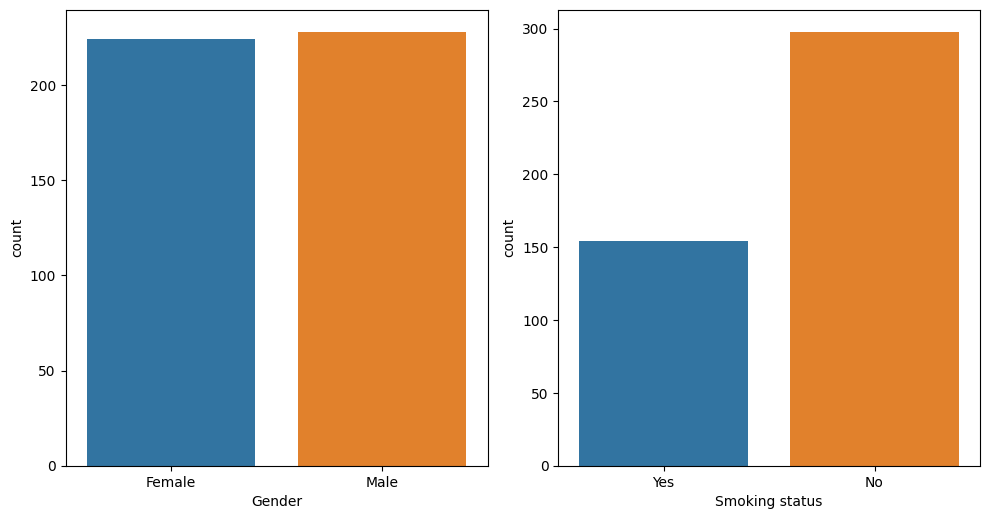

In [66]:
cat_col = data.select_dtypes(include=['object', 'category']).columns.tolist()

plt.figure(figsize=(10, 10))

def plot_charts(df, id, col):
    plt.subplot(2, 2, id)
    sns.countplot(data=df, x=col, hue=col)

for id, col in enumerate(cat_col):
    plot_charts(data, id+1, col)

plt.tight_layout()
plt.show()


# Outlier Detection

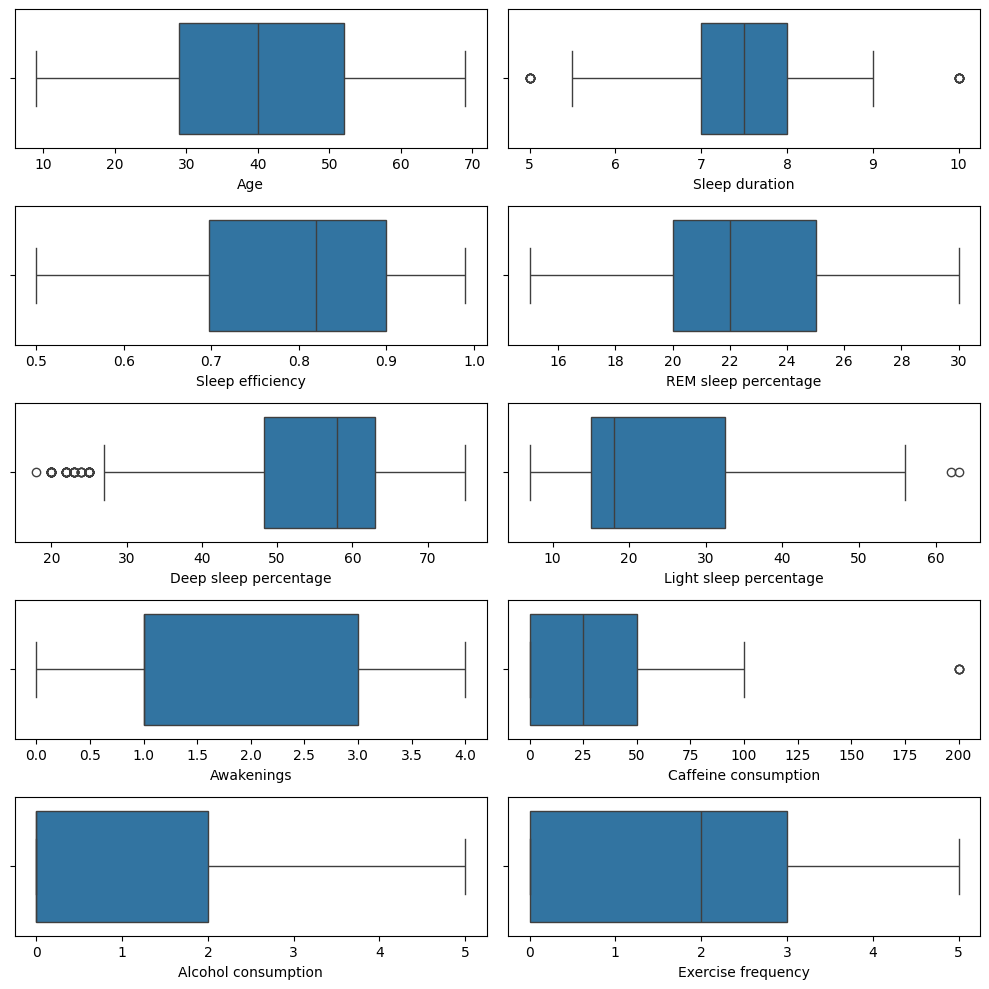

In [67]:
plt.figure(figsize=(10,10))
def box_plot(df:pd.DataFrame, id: int, col: str) -> pd.DataFrame:
    plt.subplot(5, 2, id)
    sns.boxplot(data, x=col)

for id, col in enumerate(data.select_dtypes(include=['int', 'float']).columns.tolist()):
    box_plot(data, id+1, col)

plt.tight_layout()
plt.show()
    

In [70]:
from sklearn.model_selection import train_test_split

x = data.drop("Sleep efficiency", axis=1)
y = data['Sleep efficiency']

print(np.array(x.iloc[:1]))

[[65 'Female' 6.0 18 70 12 0.0 0.0 0.0 'Yes' 3.0]]
